# WSA_05 — Comparative Visualizations

**Purpose.** Create decision-oriented charts for scenario deltas, FSA/horizon sensitivity, and alert transitions.

> Run from the project repository. Outputs are generated only from the project data and frozen model artifacts.

In [1]:
# Import libraries
from pathlib import Path
import sys, json, pandas as pd, numpy as np, matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
CONFIG = PROJECT_ROOT / "configs" / "weather_sensitivity.yaml"
CONFIG

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/weather_sensitivity.yaml')

In [3]:
# Import modules for weather_sensitivity
from src.ontario_peak_risk.weather_sensitivity.common import load_config, ensure_dirs

In [4]:
cfg, project_root = load_config(CONFIG)
paths = ensure_dirs(cfg, project_root)
print("Project root:", project_root)

Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk


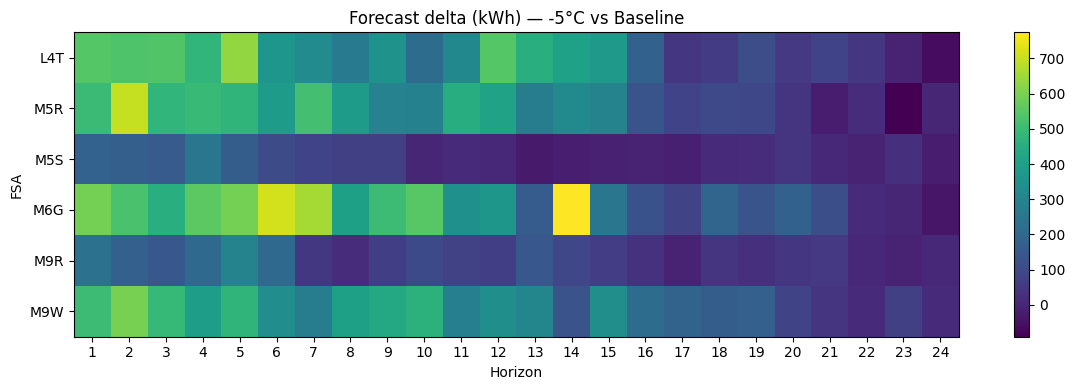

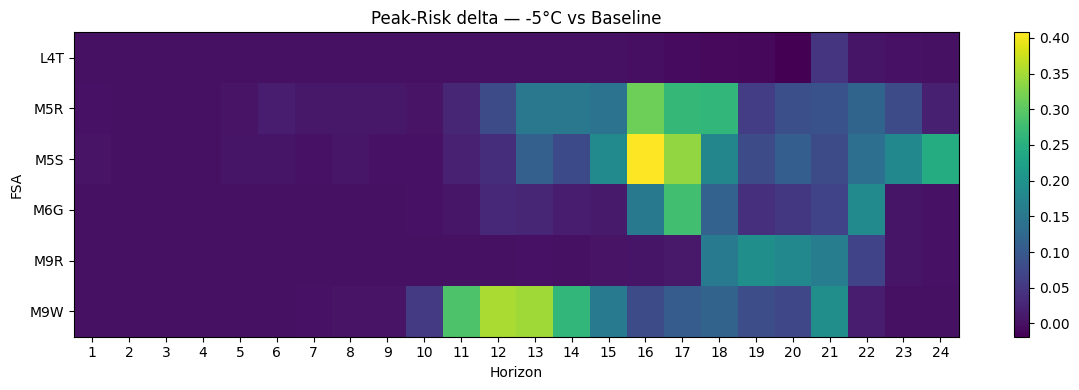

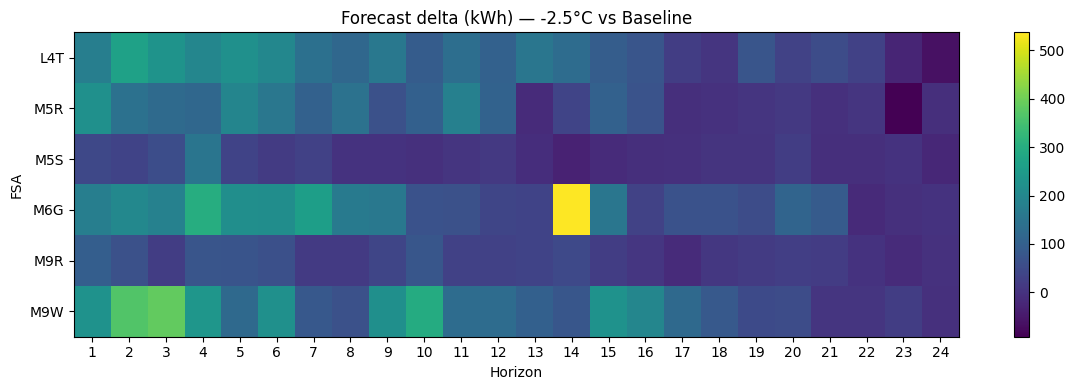

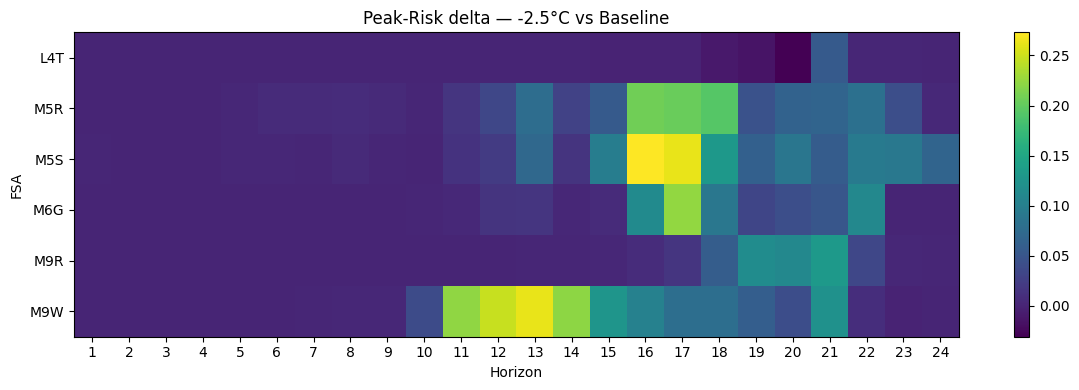

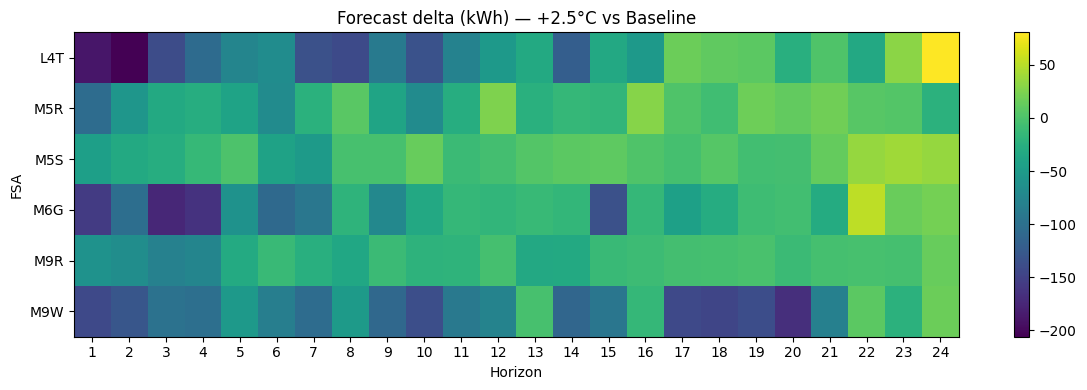

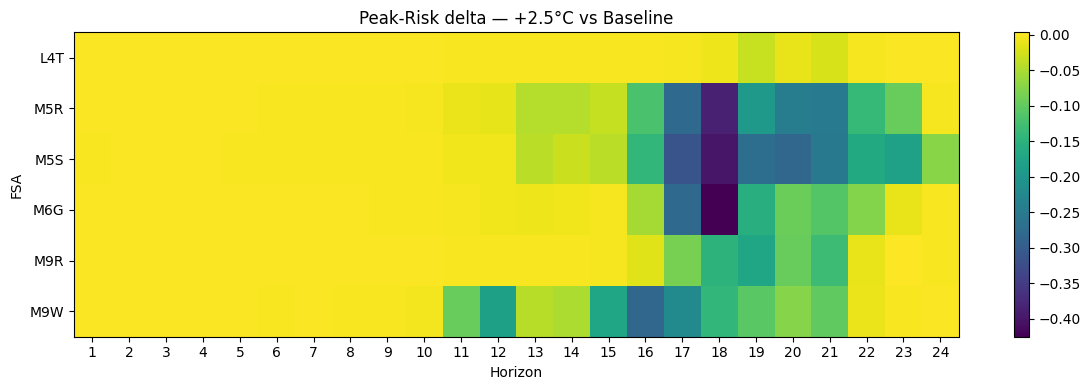

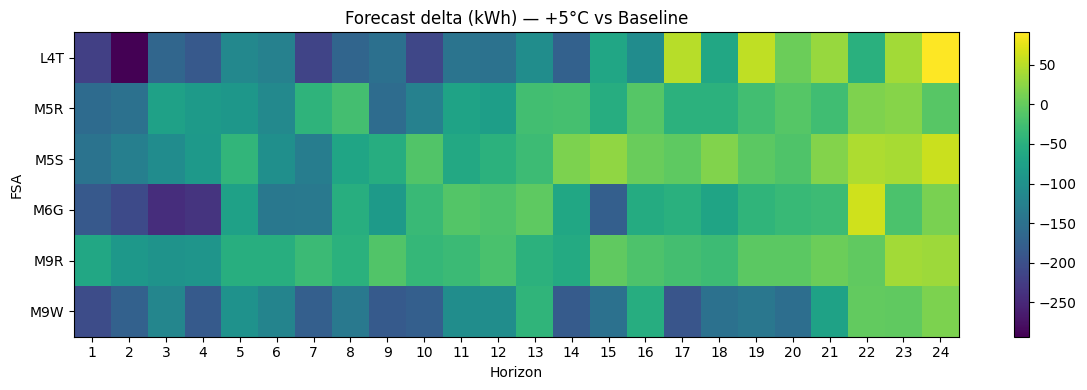

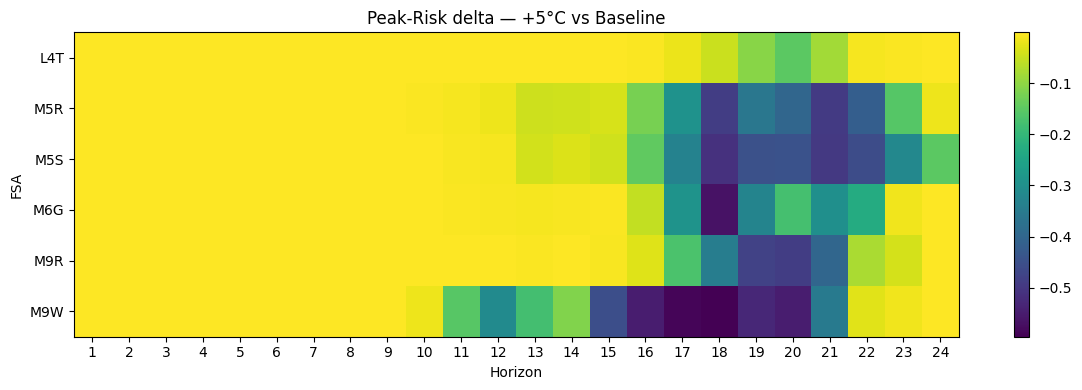

WSA_05 RESULT: COMPLETE


In [5]:
from src.ontario_peak_risk.weather_sensitivity.plotting import heatmap

r = pd.read_parquet(paths["outputs_dir"] / "WSA_sensitivity_master.parquet")
for delta in [-5.0, -2.5, 2.5, 5.0]:
    d = r[r.temperature_delta_c.eq(delta)]
    for value, label in [
        ("forecast_delta_kwh", "Forecast delta (kWh)"),
        ("peak_risk_delta", "Peak-Risk delta"),
    ]:
        fig = heatmap(d, value, f"{label} — {delta:+g}°C vs Baseline")
        fig.savefig(
            paths["figures_dir"] / f"WSA_05_{value}_{delta:+g}C_heatmap.png",
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)
print("WSA_05 RESULT: COMPLETE")

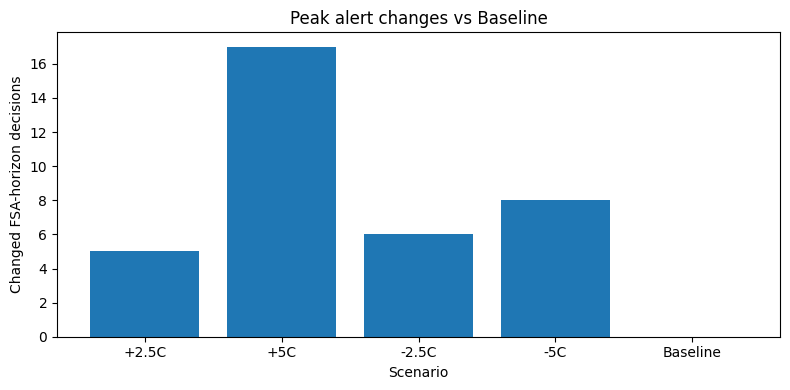

,scenario,alert_changed
0,+2.5C,5
1,+5C,17
2,-2.5C,6
3,-5C,8
4,Baseline,0


In [6]:
# Alert-change counts by scenario
counts = r.groupby("scenario", observed=True)["alert_changed"].sum().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts["scenario"], counts["alert_changed"])
ax.set(
    title="Peak alert changes vs Baseline",
    ylabel="Changed FSA-horizon decisions",
    xlabel="Scenario",
)
fig.tight_layout()
fig.savefig(
    paths["figures_dir"] / "WSA_05_alert_changes.png", dpi=160, bbox_inches="tight"
)
plt.show()
plt.close(fig)
display(counts)